## Quiver plot

**Here, we will do a quick demonstration of how to calculate surface orientations in phase field modeling.**

* Start with a given order parameter (field variable) distribution. Note that the order parameter takes a uniform value in a phase. The regions that the order parameter transitions from value to another are the interface regions.

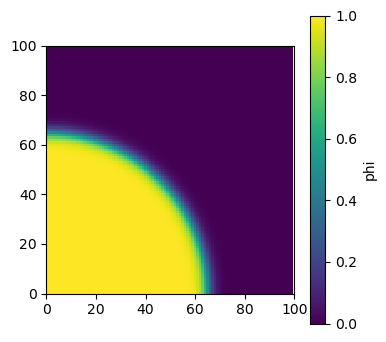

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# domain size
Lx = 100
Ly = 100
dx = 1.0

dst = np.zeros((Ly,Lx))
phi = np.zeros((Ly,Lx))

zeta = 3.0*dx;

# calculate the distabce funtion (to a given surface)
# using use a sigmoid function to create an initial order parameter fiedl
for rr in range(Ly):
    for cc in range(Lx):
        dst[rr,cc] = np.sqrt(rr**2 + cc**2)*dx
        phi[rr,cc] = 0.5*(1.0 - np.tanh((dst[rr,cc]-65.0)/zeta))


# visualization
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

im = ax.imshow(phi, origin='lower', interpolation='nearest')  
fig.colorbar(im, label='phi')


* To determine the surface orientations, we will first calculate the gradient of the order parameter. A gradient of a scalar function is a vector. So, in the 2D case, the gradient will have a $x$ and a $y$ components.

$$\nabla \phi = \bigg(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y} \bigg)$$

* The magnitude of the gradient vector is

$$\big| \nabla \phi \big| = \sqrt{\bigg(\frac{\partial \phi}{\partial x} \bigg)^2 +\bigg(\frac{\partial \phi}{\partial y} \bigg)^2} .$$

* We will use central difference method to compute the gradient:

$$\frac{\partial \phi_{i,j}}{\partial x} = \frac{\phi_{i,j+1} - \phi_{i,j-1}}{2\Delta x}$$

$$\frac{\partial \phi_{i,j}}{\partial y} = \frac{\phi_{i+1,j} - \phi_{i-1,j}}{2\Delta yt}.$$

Note that we use $i$ and $j$ for the row and column indices. Thus, $i$ corresonds to the vertical direction ($y$) and $j$ for the horizontal direction ($x$).


* Note that the central difference method cannot calculate the gradient values on the box boundaries. Thus, we calculate only the values of interior points.

In [4]:
# use central difference method to compute gradient

grd = np.zeros((Ly,Lx,2))

# in the x direction, here we use index 0 for the x component
grd[1:-1,1:-1,0] = (phi[1:-1,2:] - phi[1:-1,0:-2])/(2*dx)

# in the x direction, here we use index 0 for the x component
grd[1:-1,1:-1,1] = (phi[2:,1:-1] - phi[0:-2,1:-1])/(2*dx)


* In the bulk region, the gradient is zero. The only non-zero regions are on the interface. As a result, we shall set up a mask to calculate the surface normal only in the interfacial regions. We can define the interfacial regions as, for example:

$$\big| \nabla \phi \big| > 1\times 10 ^{-3}.$$

* plot the magnitude of $\big| \nabla \phi \big|$.

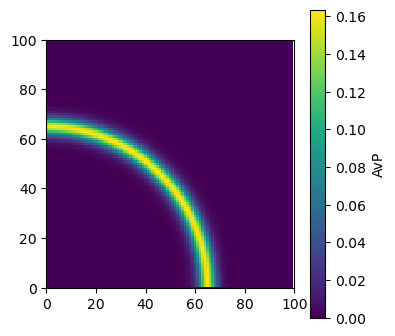

In [6]:
# calculate the magnitude of the gradient

AvP = np.zeros((Ly,Lx))
AvP[1:-1,1:-1] = np.sqrt(grd[1:-1,1:-1,0]**2 + grd[1:-1,1:-1,1]**2)

# define a mask, below which the value is set tp be 0
mask = AvP[1:-1,1:-1] > 1e-3
AvP[1:-1,1:-1][~mask] = 0.0


# visualization
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

im = ax.imshow(AvP, origin='lower', interpolation='nearest')  
fig.colorbar(im, label='AvP')

### Quiver plot of the gradient vector

* Let's calculate the unit inward vector of the interface. The inward vectors point to $\phi = 1$ from $\phi=0$.
* The unit inward vectors on a diffuse interface in the phase field model are calculated using

$$n_x = \frac{1}{|\nabla \phi \big|} \cdot \frac{\partial \phi}{\partial x}$$

$$n_y = \frac{1}{|\nabla \phi \big|} \cdot \frac{\partial \phi}{\partial y}.$$

* Plot the vectors, which indicate the locations of interface. In the quiver plot we need the arrays of the positions of the grid points.

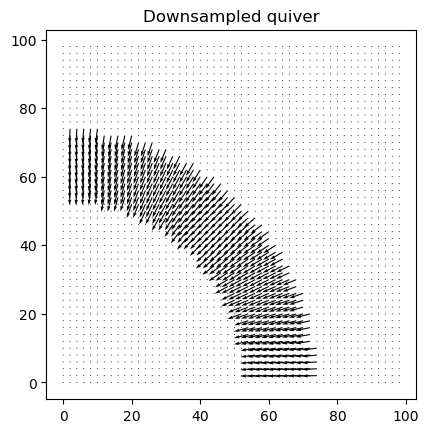

In [8]:
# unit inward vector
nv_x = np.zeros((Ly,Lx))
nv_y = np.zeros((Ly,Lx))

nv_x[1:-1,1:-1][mask] = grd[1:-1,1:-1,0][mask]/AvP[1:-1,1:-1][mask]
nv_y[1:-1,1:-1][mask] = grd[1:-1,1:-1,1][mask]/AvP[1:-1,1:-1][mask]

# make a quiverplot for the vector
ny, nx = phi.shape
x = np.arange(nx)
y = np.arange(ny)
X, Y = np.meshgrid(x, y)

step = 2  # plot every 5th point
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    nv_x[::step, ::step],
    nv_y[::step, ::step],
    color='k',
    scale=25,
    width=0.003,)

plt.gca().set_aspect('equal', adjustable='box')
plt.title('Downsampled quiver')
plt.show()

### Surface orientation

The surface orientation can be calculated using

$$\theta = \tan^{-1}\bigg(\frac{n_y}{n_x} \bigg).$$

* We can use np.arctan2($n_y$,$n_x$) function.
* Again, we only calculate the values in the interfacial region.
* Plot the obtained surface orientation.

Text(0.5, 1.0, 'degree')

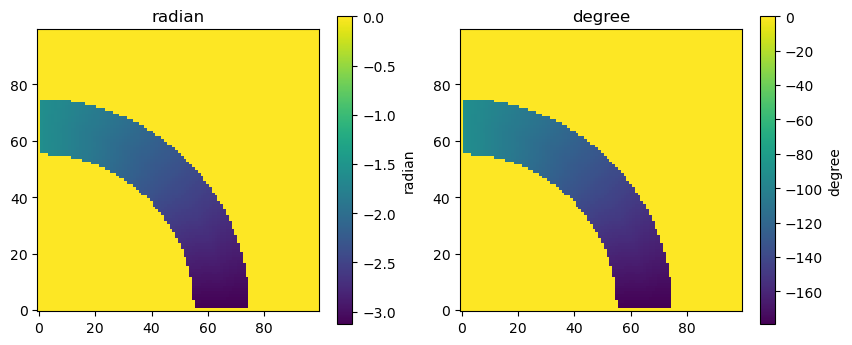

In [10]:
# surface orientation
# angle in radian
theta = np.zeros((Ly,Lx))
theta[1:-1,1:-1][mask] = np.arctan2(nv_y[1:-1,1:-1][mask],nv_x[1:-1,1:-1][mask])

# angle in degree
theta_d = np.zeros((theta.shape))
theta_d = theta/(2*np.pi)*360

# visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# --- left plot ---
im0 = axes[0].imshow(theta, origin='lower', interpolation='nearest', cmap='viridis')
cbar0 = fig.colorbar(im0, ax=axes[0], label='radian')
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_title('radian')

# --- right plot ---
im1 = axes[1].imshow(theta_d, origin='lower', interpolation='nearest', cmap='viridis')
cbar1 = fig.colorbar(im1, ax=axes[1], label='degree')
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('degree')